# Step 6: Explore Additional Plotting Options


This notebook gives you a few more ways to inspect the same QC-passed metrics and waveforms. You will make an event-aligned station-event waveform map, compare observed and synthetic station patterns, and use the flexible scatterplot, boxplot, and heatmap helpers for quick metric checks.


## Imports

These helpers read the saved tutorial products and create the additional figures.


In [1]:
from spatial_vtk.config.notebook import notebook_timer, register_svtk_cell_timer

with notebook_timer():
    from pathlib import Path

    import pandas as pd
    from IPython.display import display

    from spatial_vtk.config import SpatialVTKConfig
    from spatial_vtk.io import read_config_table
    from spatial_vtk.qc import build_qc_waveform_comparison_records
    from spatial_vtk.spatial.calculate import add_geojson_metadata_to_metrics, build_pattern_similarity_station_anomalies
    from spatial_vtk.spatial.plot import boxplot, heatmap, plot_pattern_similarity, scatterplot
    from spatial_vtk.visualize.waveforms import plot_station_event_waveform_map

register_svtk_cell_timer()

Run time: 5.05 s


## Configuration

Load the tutorial config, then choose the event, component, metric values, and figure folder used on this page.


In [2]:
# Use the repository root so paths match the public source checkout.
repo_root = Path.cwd()
config_path = repo_root / "data/examples/configuration/example_spatial_vtk_config.yaml"

# Load the tutorial run scenario and make it active for Spatial-VTK helper calls.
cfg = SpatialVTKConfig.from_file(config_path, run_scenario="tutorial").activate()

# Use the larger QC-passed metric snapshot so the flexible plots have enough rows.
metric_source_path = cfg.path("paths.metric_figure_snapshot", must_exist=True)

# Save all figures for this page in the configured tutorial figure folder.
figure_dir = cfg.path("outputs.figures")
figure_dir.mkdir(parents=True, exist_ok=True)

# The waveform map shows one event so the station ordering and event-time alignment are easy to inspect.
waveform_event_id = "ci38038071"
waveform_component = "R"
waveform_passband = "1-2 sec"
waveform_time_limit_s = 90.0

# The metric plots use common residual and score columns from the long metric table.
model_name = "cvmsi"
value_column = "log2_residual"
passbands = ["1-2 sec", "2-3 sec"]
component = "Z"

Run time: 42.5 ms


## Load Tutorial Inputs

This notebook reads committed tutorial inputs directly so it can run by itself from a fresh checkout. The metric snapshot already contains QC-passed rows, and the waveform map uses the committed lowpass-1-Hz processed MiniSEED files.

In [3]:
# Read the committed event-station and event metadata used by the tutorial scenario.
event_stations = read_config_table("paths.event_station_table")
events = read_config_table("paths.event_metadata")

# Point the waveform figure helper at the committed processed waveform files.
processed_waveform_root = repo_root / "data/examples/example_five_event_subset/processed/lowpass_1hz"
event_stations["observed_processed_waveform"] = event_stations["event_id"].map(
    lambda event_id: str(processed_waveform_root / "observed" / f"{event_id}.mseed")
)
event_stations["synthetic_processed_waveform"] = event_stations["event_id"].map(
    lambda event_id: str(processed_waveform_root / "synthetics" / "cvmsi_20260506_material_0p6x1p2_asdf" / f"{event_id}.mseed")
)

# Read the larger QC-passed metric table used for plotting examples.
metrics = pd.read_parquet(metric_source_path)

# Derive comparison-eligible waveform rows from the committed QC-passed metric snapshot.
comparison_eligible = (
    metrics.loc[
        metrics["comparison_qc_status"].astype(str).str.lower().eq("pass"),
        ["event_id", "station", "component", "passband", "distance_km"],
    ]
    .drop_duplicates()
    .copy()
)

# Add station-region labels from the tutorial GeoJSON polygons.
metrics_with_regions = add_geojson_metadata_to_metrics(metrics, target="station", selector="all")
region_metrics = metrics_with_regions.loc[metrics_with_regions["station_geojson_labels"].astype(str).ne("")].copy()
region_metrics["station_geojson_region"] = region_metrics["station_geojson_labels"].astype(str)

# Look up the selected event name for figure titles.
waveform_event_name = events.loc[events["event_id"].astype(str).eq(waveform_event_id), "event_name"].dropna().astype(str).iloc[0]

# Show the size of the metric table used by the plotting examples.
pd.DataFrame(
    {
        "Input": ["Metric rows", "Events", "Stations", "Metrics"],
        "Value": [
            len(metrics),
            metrics["event_id"].nunique(),
            metrics["station"].nunique(),
            ", ".join(sorted(metrics["metric"].dropna().astype(str).unique())),
        ],
    }
)

,Input,Value
0,Metric rows,1024
1,Events,5
2,Stations,27
3,Metrics,"CAV, FAS, PGA, PGD, PGV, PSA"


Run time: 1.94 s


## Station-Event Waveform Map

Start with a waveform view for one event. The traces are QC-passed observed records, sorted by source-to-station distance with the nearest station at the bottom. The time axis is seconds since event origin, so the observed traces are aligned to the event time before plotting.


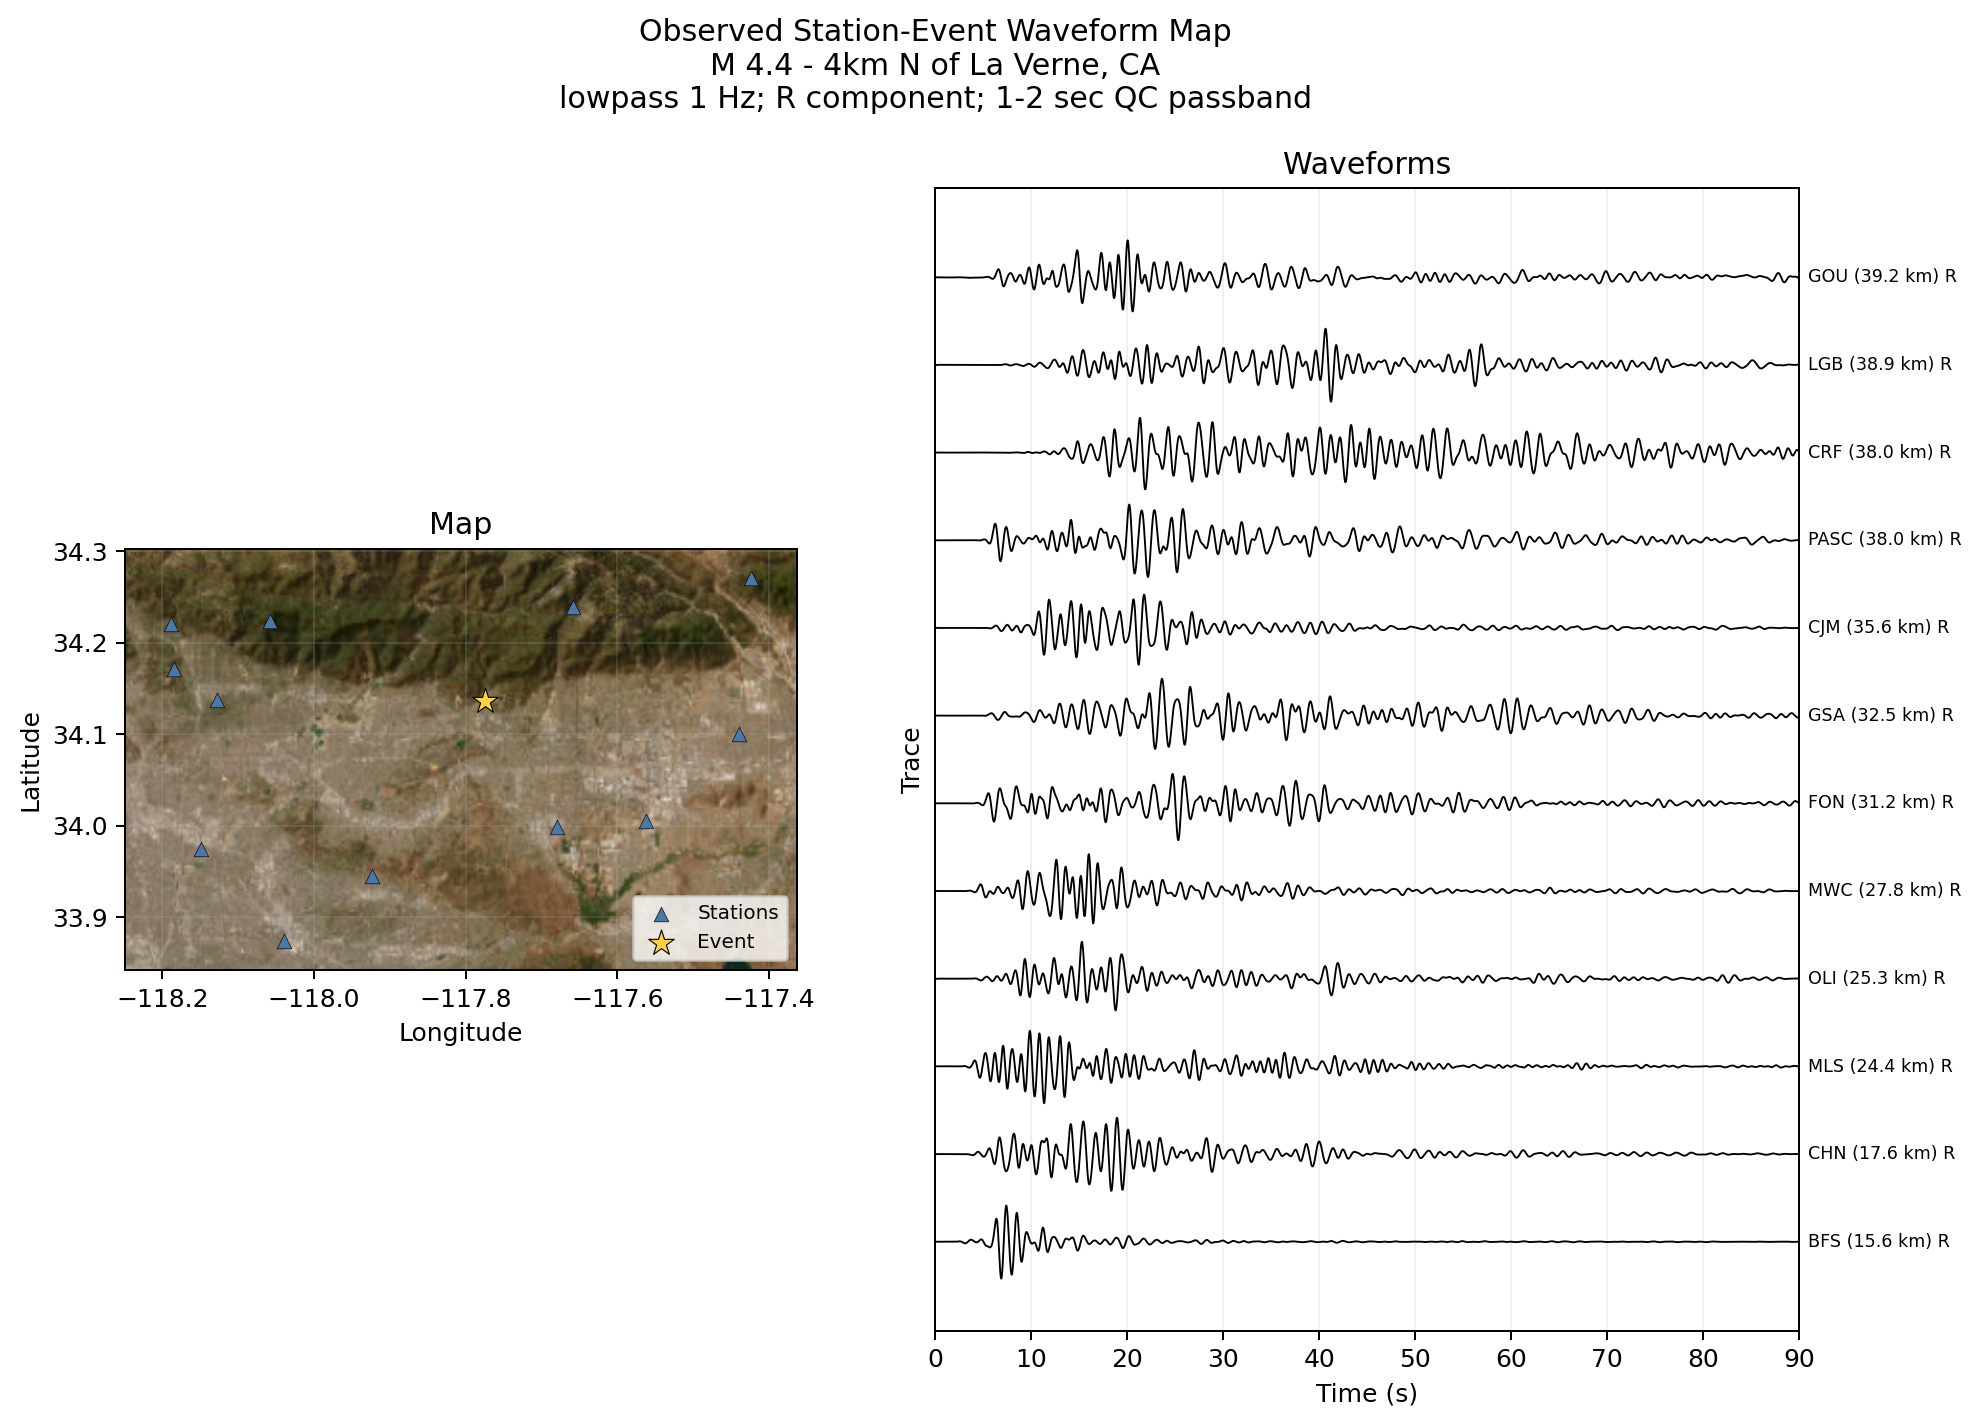

,station,distance_km
0,BFS,15.605010
1,CHN,17.585028
2,MLS,24.432927
3,OLI,25.337081
4,MWC,27.826824
5,FON,31.163268
6,GSA,32.519565
7,CJM,35.555452
8,PASC,37.979820
9,CRF,38.007905


Run time: 4.16 s


In [4]:
# Load QC-passed observed/synthetic waveform pairs for one event and one component.
waveform_records = build_qc_waveform_comparison_records(
    event_stations,
    comparison_eligible=comparison_eligible,
    component=waveform_component,
    passband=waveform_passband,
    event_id=waveform_event_id,
    max_distance_km=None,
    max_records=12,
)

# Plot the observed station-event waveform map with t=0 aligned to the event origin.
waveform_map = plot_station_event_waveform_map(
    waveform_records,
    waveform_col="observed",
    time_limit_s=waveform_time_limit_s,
    normalize=True,
    title=f"Observed Station-Event Waveform Map\n{waveform_event_name}",
    filter_label=f"lowpass 1 Hz; {waveform_component} component; {waveform_passband} QC passband",
    showfig=True,
    savefig=True,
    outpath=figure_dir / "step_06_station_event_waveform_map.png",
)

# Preview the station order used in the waveform panel.
waveform_records[["station", "distance_km"]].sort_values("distance_km").head(12)

## Pattern Similarity

Pattern similarity compares whether observed and synthetic station anomalies have the same spatial pattern for a selected metric and period band. Here, each point is a station mean after removing the dataset-wide station mean.


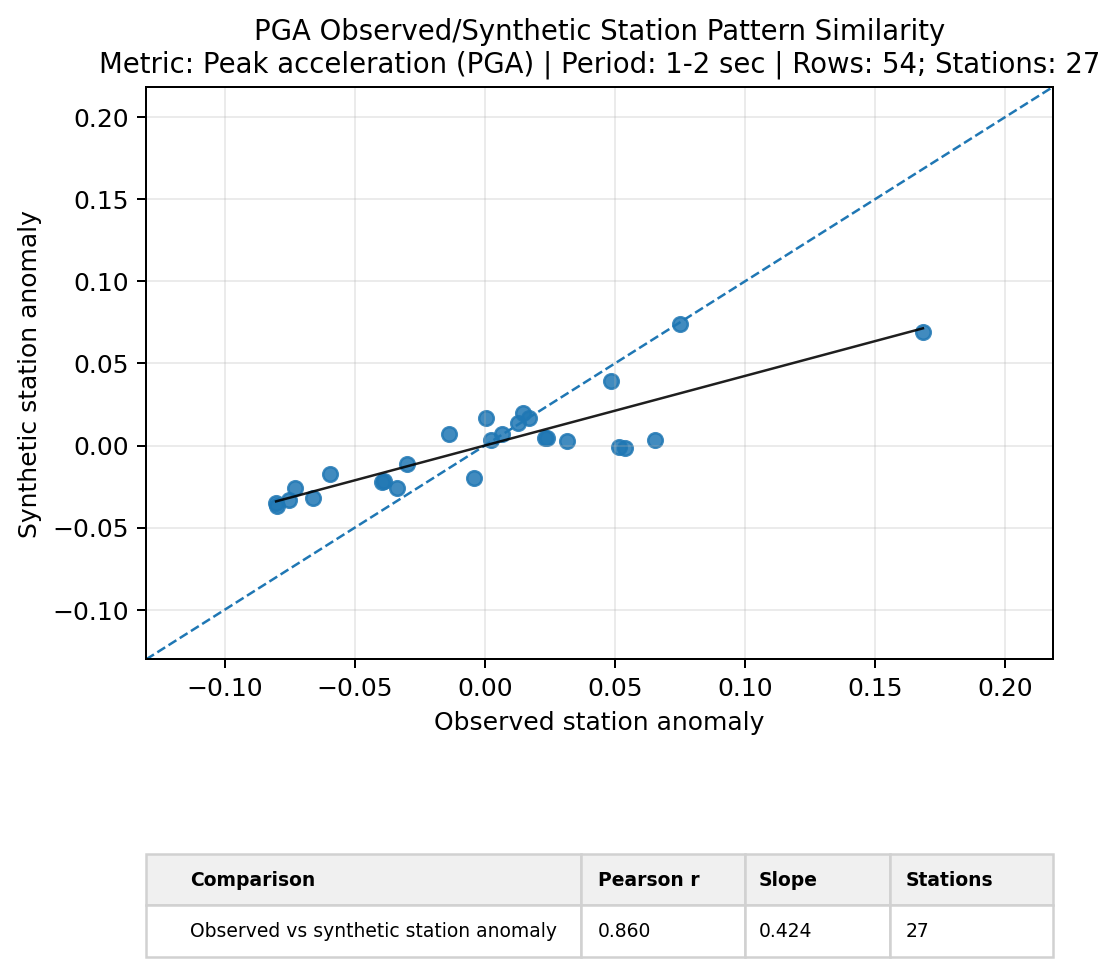

Run time: 596.0 ms


In [5]:
# Build observed/synthetic station-anomaly rows for one metric and period band.
pattern_rows = build_pattern_similarity_station_anomalies(
    metrics,
    metric="PGA",
    passband="1-2 sec",
    component=component,
    model=model_name,
)

# Plot observed station anomalies against synthetic station anomalies.
pattern_similarity_fig = plot_pattern_similarity(
    pattern_rows,
    metric="PGA",
    bin_label="1-2 sec",
    title="PGA Observed/Synthetic Station Pattern Similarity",
    fit="linear",
    showfig=True,
    savefig=True,
    outpath=figure_dir / "step_06_pattern_similarity.png",
)

## Flexible Metric Plots

The flexible plotting helpers let you inspect columns in the long metric table without manually reshaping the dataframe. You pass the table, the variables you want on the axes, and any filters such as metric, period band, model, or component.


### Scatterplot

This scatterplot compares PGA and PGV residuals against source-to-station distance. The LOWESS curves help you see broad trends without assuming a straight-line relationship.


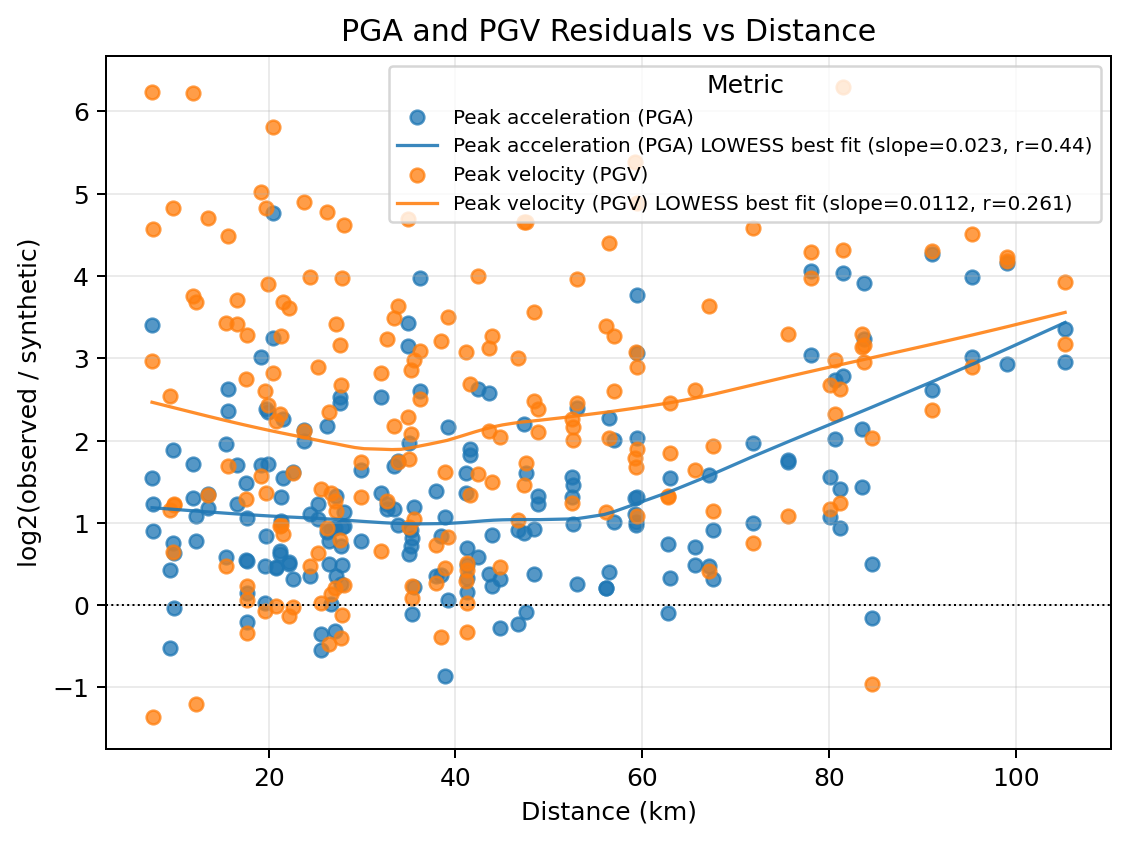

Run time: 933.1 ms


In [6]:
# Plot PGA and PGV residuals against source-to-station distance with LOWESS curves.
metric_scatter = scatterplot(
    data=metrics,
    indep="distance",
    dep=["PGA", "PGV"],
    value_col=value_column,
    passband=passbands,
    model=model_name,
    component=component,
    colorby="dep",
    fit="lowess",
    title="PGA and PGV Residuals vs Distance",
    showfig=True,
    savefig=True,
    outpath=figure_dir / "step_06_metric_scatterplot.png",
)

### Boxplot

The boxplot groups residuals by the tutorial GeoJSON regions. Passing `compare_to="LA Basin"` adds a small table that compares the other regions against the basin baseline.


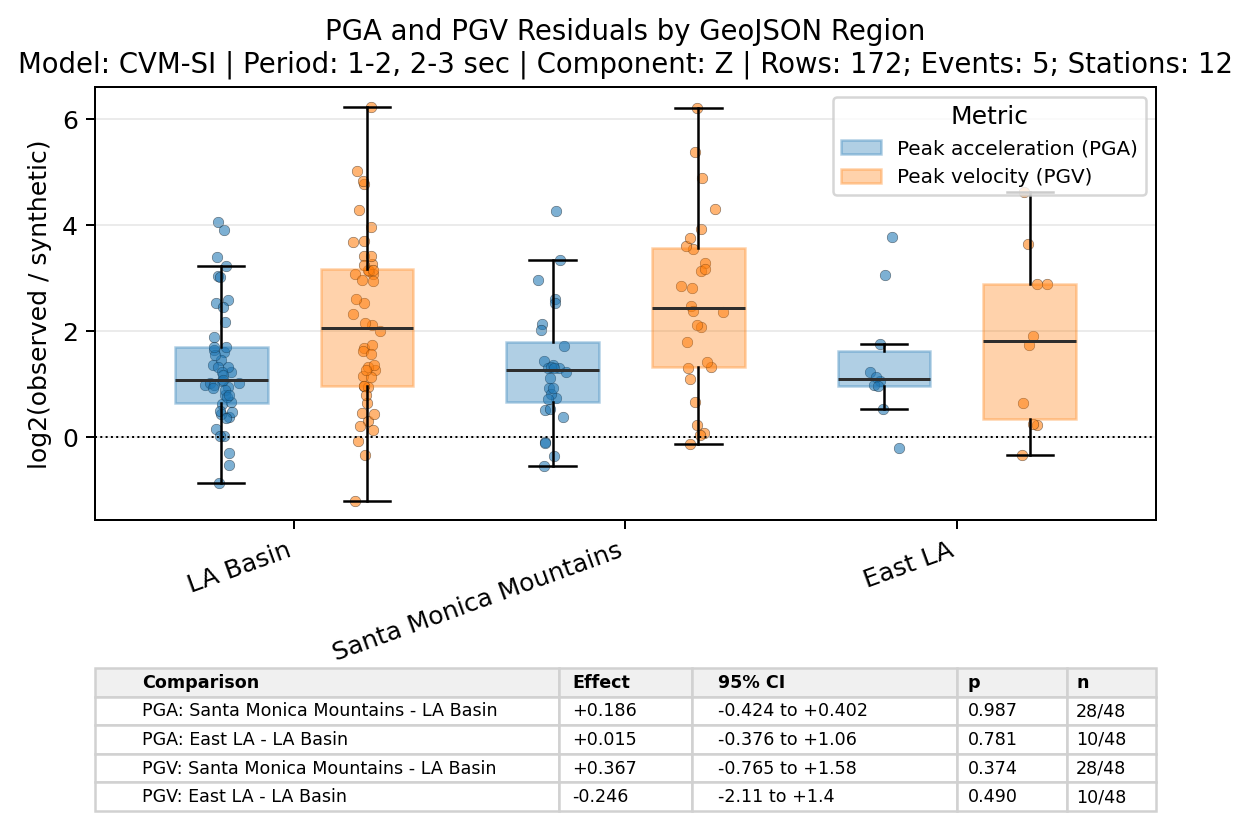

Run time: 1.68 s


In [7]:
# Plot PGA and PGV residual distributions by tutorial GeoJSON region.
metric_boxplot = boxplot(
    data=region_metrics,
    dep=["PGA", "PGV"],
    indep="station_geojson_region",
    value_col=value_column,
    passband=passbands,
    model=model_name,
    component=component,
    compare_to="LA Basin",
    table=True,
    title="PGA and PGV Residuals by GeoJSON Region",
    showfig=True,
    savefig=True,
    outpath=figure_dir / "step_06_metric_boxplot.png",
)

### Heatmap

The heatmap gives a compact categorical summary. In this example, each cell is the mean log2 residual for a metric and tutorial GeoJSON region.


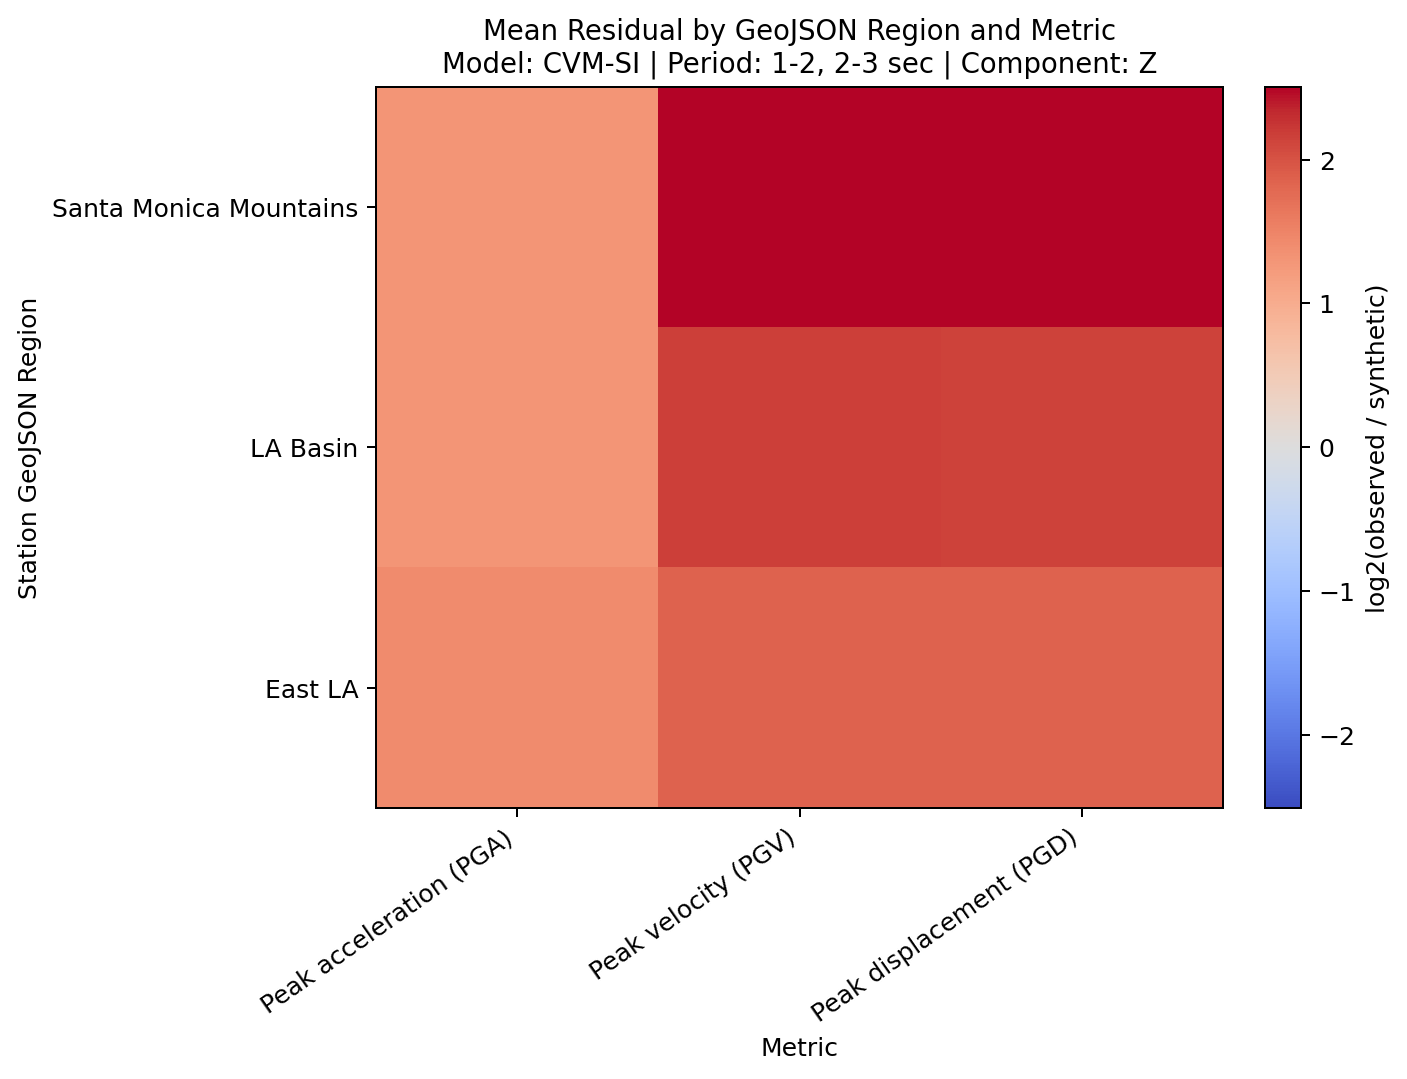

Run time: 1.03 s


In [8]:
# Plot mean residuals by tutorial GeoJSON region and metric.
metric_heatmap = heatmap(
    data=region_metrics,
    dep=["PGA", "PGV", "PGD"],
    indep="station_geojson_region",
    value_col=value_column,
    passband=passbands,
    model=model_name,
    component=component,
    aggfunc="mean",
    title="Mean Residual by GeoJSON Region and Metric",
    showfig=True,
    savefig=True,
    outpath=figure_dir / "step_06_metric_heatmap.png",
)

## Next Step

The next notebook uses the same QC and metric outputs to prepare the interactive dashboard inputs.
